In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Change only this line to match your Mac username
USERNAME = "shreya"  # <- she changes this to her username

BASE_PATH = f"/Users/{USERNAME}/Desktop/ARIA/data"

df = pd.read_csv(f"{BASE_PATH}/healthcare_readmission.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [10]:
pip install seaborn


     |████████████████████████████████| 294 kB 1.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/shreya/Desktop/ARIA/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Change only this line to match your Mac username
USERNAME = "shreya"  # <- she changes this to her username

BASE_PATH = f"/Users/{USERNAME}/Desktop/ARIA/data"

df = pd.read_csv(f"{BASE_PATH}/healthcare_readmission.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (25000, 17)

Columns: ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [3]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

Data Types:
 age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

Missing Values:
 age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

Basic Stats:
        time_in_hospital  n_lab_procedures  n_procedures  n_m

In [4]:
print("Target column values:")
print(df['readmitted'].value_counts())
print("\nData type:", df['readmitted'].dtype)

Target column values:
readmitted
no     13246
yes    11754
Name: count, dtype: int64

Data type: object


In [5]:
total = len(df)
print(f"Total patients: {total}")
print("\nReadmission breakdown:")
print(df['readmitted'].value_counts())
print("\nPercentages:")
print(df['readmitted'].value_counts(normalize=True) * 100)

Total patients: 25000

Readmission breakdown:
readmitted
no     13246
yes    11754
Name: count, dtype: int64

Percentages:
readmitted
no     52.984
yes    47.016
Name: proportion, dtype: float64


In [6]:
if df['readmitted'].dtype == 'object':
    print("Unique values:", df['readmitted'].unique())
    df['readmitted_binary'] = df['readmitted'].apply(
        lambda x: 1 if x in ['YES', 'yes', '<30', '>30'] else 0
    )
else:
    df['readmitted_binary'] = df['readmitted']

print("\nBinary target distribution:")
print(df['readmitted_binary'].value_counts())

Unique values: ['no' 'yes']

Binary target distribution:
readmitted_binary
0    13246
1    11754
Name: count, dtype: int64


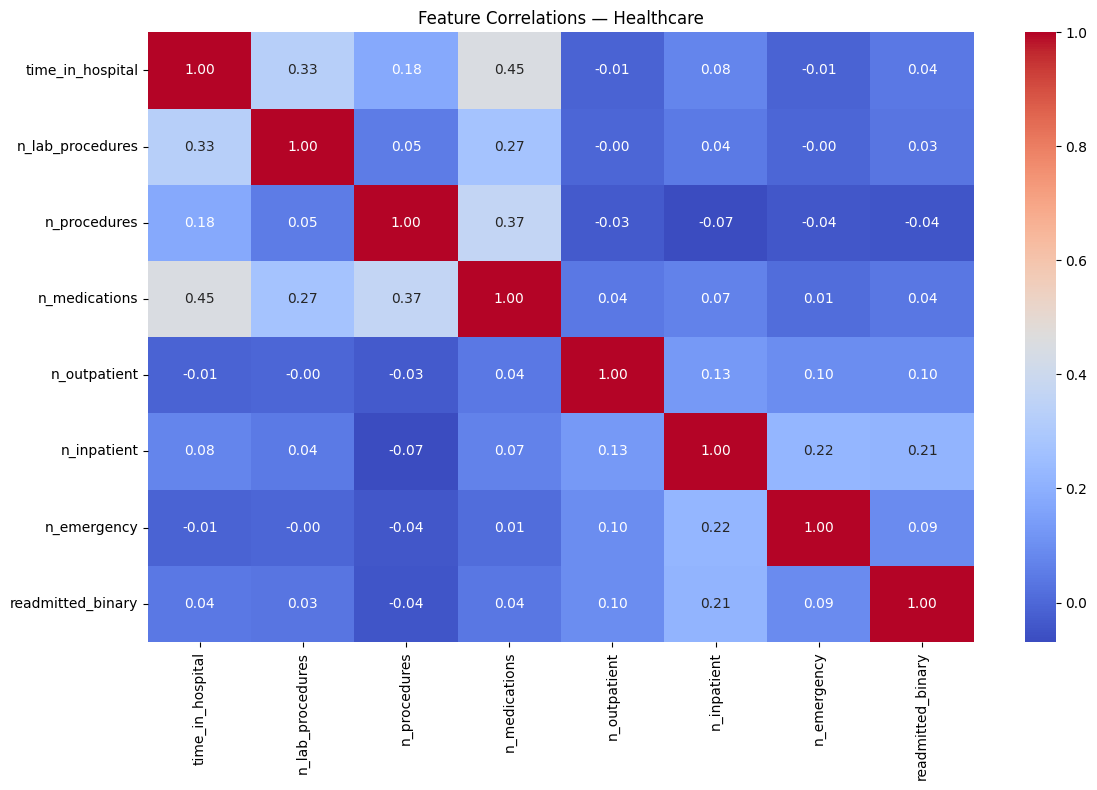

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations — Healthcare')
plt.tight_layout()
plt.show()

In [8]:
df.to_csv(f"{BASE_PATH}/healthcare_clean.csv", index=False)
print("✅ Clean file saved")
print("Shape:", df.shape)

✅ Clean file saved
Shape: (25000, 18)
